<a href="https://colab.research.google.com/github/ryo-nakajima/tamachi-restaurant-map/blob/main/gyuudon_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 牛丼チェーンの価格改定点ベースの推移

このノートブックは、価格改定イベントCSVを読み込み、価格改定があった時点のみを使って  
すき家・松屋・吉野家の並盛価格の推移を描く。

注意点:
- `effective_date` 列には `YYYY-MM-DD` と `YYYY-MM-DD HH:MM` が混在している
- pandas 2.x では、`pd.to_datetime(..., errors='coerce')` だけだと混在形式の一部が `NaT` になる
- そのため、`format='mixed'` を必ず指定する


In [ ]:
# Colab で最初に一度だけ実行
!pip -q install japanize-matplotlib

In [ ]:

# 必要ならコメントアウトを外す
# !pip install japanize-matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import japanize_matplotlib

In [ ]:
# Google Colab 専用
csv_url = "https://raw.githubusercontent.com/ryo-nakajima/undergrad-io-2026-data/main/gyudon_chain_standard_bowl_price_changes_2000_2026.csv"

chg = pd.read_csv(csv_url)

chg['effective_date'] = pd.to_datetime(
    chg['effective_date'],
    errors='coerce',
    format='mixed'
)

bad = chg[chg['effective_date'].isna()][
    ['chain', 'variant', 'effective_date_source_text', 'effective_date']
]
print('NaT rows:', len(bad))
display(bad)

events = chg[chg['new_price_in_store_jpy'].notna()].copy()

display(
    events[
        ['chain', 'variant', 'effective_date', 'event_type', 'new_price_in_store_jpy']
    ].tail(15)
)

NaT rows: 0


,chain,variant,effective_date_source_text,effective_date


,chain,variant,effective_date,event_type,new_price_in_store_jpy
22,吉野家,standard,2023-10-02 14:00:00,price_change,468.0
23,吉野家,standard,2024-07-29 14:00:00,price_change,498.0
24,松屋,standard,2000-09-01 00:00:00,price_change,290.0
26,松屋,standard,2004-10-01 00:00:00,sales_resumed,390.0
27,松屋,standard,2005-09-01 00:00:00,price_change,350.0
28,松屋,standard,2008-09-01 00:00:00,price_change,380.0
29,松屋,standard,2009-12-01 00:00:00,price_change,320.0
30,松屋,standard,2012-01-16 15:00:00,price_change,280.0
31,松屋,standard,2014-04-01 15:00:00,price_change,290.0
32,松屋,premium,2014-07-22 10:00:00,new_variant_launch,380.0


In [ ]:

# 一つの線として描く系列を作る
# すき家: standard
# 吉野家: standard
# 松屋: 2020年までは standard、2021年以降は unified

sukiya = events[
    (events['chain'] == 'すき家') &
    (events['variant'] == 'standard')
].copy()

yoshinoya = events[
    (events['chain'] == '吉野家') &
    (events['variant'] == 'standard')
].copy()

matsuya_standard = events[
    (events['chain'] == '松屋') &
    (events['variant'] == 'standard')
].copy()

matsuya_unified = events[
    (events['chain'] == '松屋') &
    (events['variant'] == 'unified')
].copy()

matsuya = pd.concat([matsuya_standard, matsuya_unified], ignore_index=True)

def slim(df):
    out = df[['effective_date', 'new_price_in_store_jpy']].copy()
    out = out.dropna(subset=['effective_date', 'new_price_in_store_jpy'])
    out = out.sort_values('effective_date')
    out = out.drop_duplicates(subset=['effective_date'], keep='last')
    return out

sukiya_plot = slim(sukiya)
yoshinoya_plot = slim(yoshinoya)
matsuya_plot = slim(matsuya)

print('すき家')
display(sukiya_plot)
print('松屋')
display(matsuya_plot)
print('吉野家')
display(yoshinoya_plot)


すき家


,effective_date,new_price_in_store_jpy
0,2001-03-01 00:00:00,280.0
2,2004-09-01 00:00:00,350.0
3,2009-04-23 00:00:00,330.0
4,2009-12-07 09:00:00,280.0
5,2014-04-01 00:00:00,270.0
6,2014-08-27 00:00:00,291.0
7,2015-04-15 00:00:00,350.0
8,2021-12-23 09:00:00,400.0
9,2024-04-03 09:00:00,430.0
10,2024-11-22 09:00:00,450.0


松屋


,effective_date,new_price_in_store_jpy
0,2000-09-01 00:00:00,290.0
1,2004-10-01 00:00:00,390.0
2,2005-09-01 00:00:00,350.0
3,2008-09-01 00:00:00,380.0
4,2009-12-01 00:00:00,320.0
5,2012-01-16 15:00:00,280.0
6,2014-04-01 15:00:00,290.0
7,2018-04-03 14:00:00,320.0
8,2021-09-28 14:00:00,380.0
9,2023-03-21 15:00:00,400.0


吉野家


,effective_date,new_price_in_store_jpy
13,2001-07-26 00:00:00,280.0
15,2006-09-18 00:00:00,380.0
16,2013-04-18 10:00:00,280.0
17,2014-04-01 10:00:00,300.0
18,2014-12-17 15:00:00,380.0
19,2019-10-01 10:00:00,387.0
20,2021-10-29 15:00:00,426.0
21,2022-10-01 14:00:00,448.0
22,2023-10-02 14:00:00,468.0
23,2024-07-29 14:00:00,498.0


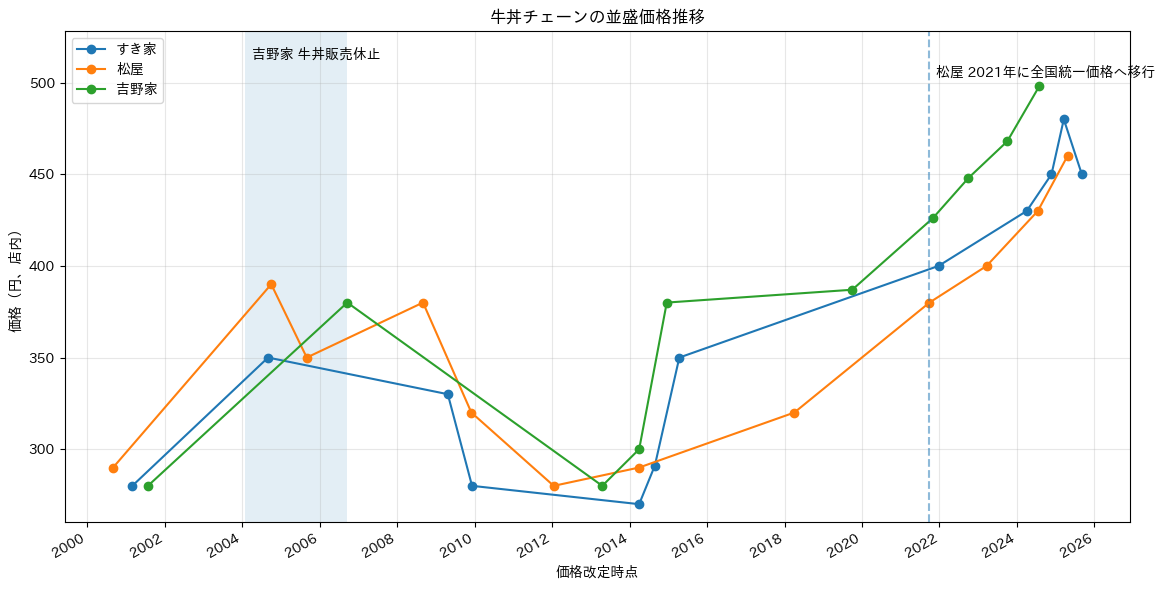

In [ ]:

# プロット
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    sukiya_plot['effective_date'],
    sukiya_plot['new_price_in_store_jpy'],
    marker='o',
    label='すき家'
)

ax.plot(
    matsuya_plot['effective_date'],
    matsuya_plot['new_price_in_store_jpy'],
    marker='o',
    label='松屋'
)

ax.plot(
    yoshinoya_plot['effective_date'],
    yoshinoya_plot['new_price_in_store_jpy'],
    marker='o',
    label='吉野家'
)

# 吉野家の販売休止期間
ax.axvspan(
    pd.Timestamp('2004-02-01'),
    pd.Timestamp('2006-09-18'),
    alpha=0.12
)

# 松屋の2021年全国統一価格移行
ax.axvline(
    pd.Timestamp('2021-09-28'),
    linestyle='--',
    alpha=0.5
)

# 軸の体裁
ax.set_xlabel('価格改定時点')
ax.set_ylabel('価格（円、店内）')
ax.set_title('牛丼チェーンの並盛価格推移')
ax.legend()
ax.grid(alpha=0.3)

ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 注記は軸内に置く
ymax = max(
    sukiya_plot['new_price_in_store_jpy'].max(),
    matsuya_plot['new_price_in_store_jpy'].max(),
    yoshinoya_plot['new_price_in_store_jpy'].max()
)
ax.set_ylim(260, ymax + 30)

ax.text(pd.Timestamp('2004-04-01'), ymax + 15, '吉野家 牛丼販売休止', fontsize=10)
ax.text(pd.Timestamp('2021-12-01'), ymax + 5, '松屋 2021年に全国統一価格へ移行', fontsize=10)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()
